# 05 - DCA Model Comparison

In this notebook, we compare the per-well decline curve analysis models built so far.

Models included:

- Exponential decline
- Hyperbolic decline
- Harmonic decline

Shared evaluation setup:

- Fit window: months 12-24
- Forecast-check window: months 25-33
- Target: total oil production over the forecast-check window
- Comparison level: individual wells

Main questions:

- Which DCA model has the lowest forecast error?
- Which model has the least forecast bias?
- How often does each model win at the individual-well level?
- Are some wells difficult for all smooth decline models?
- Does the added flexibility of hyperbolic decline improve forecast performance enough to justify the extra parameter?

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [4]:
OUTPUT_DIR = Path("outputs")

In [6]:
sorted([path.name for path in OUTPUT_DIR.glob("*.csv")])

['dca_exponential_vs_hyperbolic_model_summary.csv',
 'dca_exponential_vs_hyperbolic_win_counts.csv',
 'dca_metric_comparison_exponential_vs_hyperbolic.csv',
 'dca_per_well_exponential_vs_hyperbolic_comparison.csv',
 'example_best_and_worst_exponential_dca_wells.csv',
 'example_best_and_worst_hyperbolic_dca_wells.csv',
 'harmonic_decline_fit_summary.csv',
 'harmonic_decline_metrics.csv',
 'hyperbolic_decline_fit_summary.csv',
 'hyperbolic_decline_metrics.csv',
 'median_harmonic_decline_curve.csv',
 'median_hyperbolic_decline_curve.csv',
 'oil_dca_diagnostic_data.csv',
 'per_well_exponential_dca_error_summary.csv',
 'per_well_exponential_dca_monthly_forecasts.csv',
 'per_well_exponential_dca_results.csv',
 'per_well_harmonic_comparison_ready.csv',
 'per_well_harmonic_dca_error_summary.csv',
 'per_well_harmonic_dca_monthly_forecasts.csv',
 'per_well_harmonic_dca_results.csv',
 'per_well_hyperbolic_comparison_ready.csv',
 'per_well_hyperbolic_dca_error_summary.csv',
 'per_well_hyperbolic_d

In [8]:
exp_results = pd.read_csv(
    OUTPUT_DIR / "per_well_exponential_dca_results.csv",
    dtype={"api8": str},
)

hyp_results = pd.read_csv(
    OUTPUT_DIR / "per_well_hyperbolic_comparison_ready.csv",
    dtype={"api8": str},
)

harm_results = pd.read_csv(
    OUTPUT_DIR / "per_well_harmonic_comparison_ready.csv",
    dtype={"api8": str},
)

exp_results.head(), hyp_results.head(), harm_results.head()

(       api8          lease_name well_no  fit_start_month  fit_end_month  \
 0  31744055      DAVIS-LACY 31K    211H               12             24   
 1  31744070      DAVIS-LACY 31C    203H               12             24   
 2  31743755  GLYNN-ATCHISON 44N    214H               12             24   
 3  31744067      DAVIS-LACY 31F    206H               12             24   
 4  31743757  GLYNN-ATCHISON 44M    213H               12             24   
 
    forecast_start_month  forecast_end_month  qi_bbl_per_month  di_per_month  \
 0                    25                  33      41030.023976      0.114282   
 1                    25                  33      21892.731349      0.111224   
 2                    25                  33      41702.860315      0.101292   
 3                    25                  33      49435.843537      0.113766   
 4                    25                  33       3894.710714      0.020590   
 
    di_percent_per_month  actual_test_oil_bbl  forecast_test

In [10]:
exp_results.shape, hyp_results.shape, harm_results.shape


((30, 15), (30, 12), (30, 12))

In [12]:
exp_comparison_ready = exp_results[
    [
        "api8",
        "lease_name",
        "well_no",
        "actual_test_oil_bbl",
        "forecast_test_oil_bbl",
        "error_bbl",
        "percent_error",
        "absolute_percent_error",
        "qi_bbl_per_month",
        "di_per_month",
        "di_percent_per_month",
    ]
].copy()

exp_comparison_ready = exp_comparison_ready.rename(
    columns={
        "forecast_test_oil_bbl": "exponential_forecast_test_oil_bbl",
        "error_bbl": "exponential_error_bbl",
        "percent_error": "exponential_percent_error",
        "absolute_percent_error": "exponential_absolute_percent_error",
        "qi_bbl_per_month": "exponential_qi_bbl_per_month",
        "di_per_month": "exponential_di_per_month",
        "di_percent_per_month": "exponential_di_percent_per_month",
    }
)

exp_comparison_ready.head()

,api8,lease_name,well_no,actual_test_oil_bbl,exponential_forecast_test_oil_bbl,exponential_error_bbl,exponential_percent_error,exponential_absolute_percent_error,exponential_qi_bbl_per_month,exponential_di_per_month,exponential_di_percent_per_month
0,31744055,DAVIS-LACY 31K,211H,49251.0,14020.293239,-35230.706761,-71.532978,71.532978,41030.023976,0.114282,11.428191
1,31744070,DAVIS-LACY 31C,203H,22233.0,8156.221462,-14076.778538,-63.314796,63.314796,21892.731349,0.111224,11.122382
2,31743755,GLYNN-ATCHISON 44N,214H,46559.0,20579.572042,-25979.427958,-55.798939,55.798939,41702.860315,0.101292,10.129168
3,31744067,DAVIS-LACY 31F,206H,38239.0,17140.781224,-21098.218776,-55.174609,55.174609,49435.843537,0.113766,11.376575
4,31743757,GLYNN-ATCHISON 44M,213H,35704.0,19320.026627,-16383.973373,-45.888341,45.888341,3894.710714,0.020590,2.059016


In [14]:
dca_model_comparison = (
    exp_comparison_ready
    .merge(
        hyp_results,
        on=["api8", "lease_name", "well_no", "actual_test_oil_bbl"],
        how="inner",
    )
    .merge(
        harm_results,
        on=["api8", "lease_name", "well_no", "actual_test_oil_bbl"],
        how="inner",
    )
)

dca_model_comparison.head()

,api8,lease_name,well_no,actual_test_oil_bbl,exponential_forecast_test_oil_bbl,exponential_error_bbl,exponential_percent_error,exponential_absolute_percent_error,exponential_qi_bbl_per_month,exponential_di_per_month,...,hyperbolic_di_percent_per_month,hyperbolic_b_factor,harmonic_forecast_test_oil_bbl,harmonic_error_bbl,harmonic_percent_error,harmonic_absolute_percent_error,harmonic_qi_bbl_per_month,harmonic_di_per_month,harmonic_di_percent_per_month,harmonic_b_factor
0,31744055,DAVIS-LACY 31K,211H,49251.0,14020.293239,-35230.706761,-71.532978,71.532978,41030.023976,0.114282,...,15.818182,0.138776,30401.491026,-18849.508974,-38.272338,38.272338,42274.629829,0.400,40.0,1.0
1,31744070,DAVIS-LACY 31C,203H,22233.0,8156.221462,-14076.778538,-63.314796,63.314796,21892.731349,0.111224,...,12.190909,0.050000,17139.533536,-5093.466464,-22.909488,22.909488,23833.286173,0.400,40.0,1.0
2,31743755,GLYNN-ATCHISON 44N,214H,46559.0,20579.572042,-25979.427958,-55.798939,55.798939,41702.860315,0.101292,...,23.475758,0.316327,39039.788433,-7519.211567,-16.149856,16.149856,54286.567828,0.400,40.0,1.0
3,31744067,DAVIS-LACY 31F,206H,38239.0,17140.781224,-21098.218776,-55.174609,55.174609,49435.843537,0.113766,...,21.057576,0.227551,36971.752007,-1267.247993,-3.314020,3.314020,51410.870898,0.400,40.0,1.0
4,31743757,GLYNN-ATCHISON 44M,213H,35704.0,19320.026627,-16383.973373,-45.888341,45.888341,3894.710714,0.020590,...,40.000000,1.500000,18050.566057,-17653.433943,-49.443855,49.443855,5939.838839,0.068,6.8,1.0


In [16]:
dca_model_comparison.shape

(30, 27)

In [18]:
dca_model_comparison["api8"].nunique()

30

In [20]:
absolute_error_columns = [
    "exponential_absolute_percent_error",
    "hyperbolic_absolute_percent_error",
    "harmonic_absolute_percent_error",
]

dca_model_comparison["best_model"] = (
    dca_model_comparison[absolute_error_columns]
    .idxmin(axis=1)
    .str.replace("_absolute_percent_error", "", regex=False)
)

dca_model_comparison[
    [
        "api8",
        "exponential_absolute_percent_error",
        "hyperbolic_absolute_percent_error",
        "harmonic_absolute_percent_error",
        "best_model",
    ]
].head()

,api8,exponential_absolute_percent_error,hyperbolic_absolute_percent_error,harmonic_absolute_percent_error,best_model
0,31744055,71.532978,68.959435,38.272338,harmonic
1,31744070,63.314796,61.726277,22.909488,harmonic
2,31743755,55.798939,49.445049,16.149856,harmonic
3,31744067,55.174609,49.213648,3.314020,harmonic
4,31743757,45.888341,50.028355,49.443855,exponential


In [22]:
dca_model_win_counts = (
    dca_model_comparison["best_model"]
    .value_counts()
    .reset_index()
)

dca_model_win_counts.columns = ["model", "well_count"]

dca_model_win_counts

,model,well_count
0,harmonic,16
1,hyperbolic,9
2,exponential,5


In [24]:
dca_model_summary = pd.DataFrame(
    [
        {
            "model": "exponential",
            "wells": len(dca_model_comparison),
            "mean_absolute_percent_error": dca_model_comparison[
                "exponential_absolute_percent_error"
            ].mean(),
            "median_absolute_percent_error": dca_model_comparison[
                "exponential_absolute_percent_error"
            ].median(),
            "mean_percent_error": dca_model_comparison[
                "exponential_percent_error"
            ].mean(),
            "median_percent_error": dca_model_comparison[
                "exponential_percent_error"
            ].median(),
        },
        {
            "model": "hyperbolic",
            "wells": len(dca_model_comparison),
            "mean_absolute_percent_error": dca_model_comparison[
                "hyperbolic_absolute_percent_error"
            ].mean(),
            "median_absolute_percent_error": dca_model_comparison[
                "hyperbolic_absolute_percent_error"
            ].median(),
            "mean_percent_error": dca_model_comparison[
                "hyperbolic_percent_error"
            ].mean(),
            "median_percent_error": dca_model_comparison[
                "hyperbolic_percent_error"
            ].median(),
        },
        {
            "model": "harmonic",
            "wells": len(dca_model_comparison),
            "mean_absolute_percent_error": dca_model_comparison[
                "harmonic_absolute_percent_error"
            ].mean(),
            "median_absolute_percent_error": dca_model_comparison[
                "harmonic_absolute_percent_error"
            ].median(),
            "mean_percent_error": dca_model_comparison[
                "harmonic_percent_error"
            ].mean(),
            "median_percent_error": dca_model_comparison[
                "harmonic_percent_error"
            ].median(),
        },
    ]
)

dca_model_summary

,model,wells,mean_absolute_percent_error,median_absolute_percent_error,mean_percent_error,median_percent_error
0,exponential,30,50.277175,31.857163,4.691979,-23.806413
1,hyperbolic,30,35.038683,27.694182,-6.608255,-20.716348
2,harmonic,30,33.006547,15.097784,19.464560,7.045700


In [29]:
dca_model_comparison.to_csv(
    OUTPUT_DIR / "dca_all_models_per_well_comparison.csv",
    index=False,
)

dca_model_summary.to_csv(
    OUTPUT_DIR / "dca_all_models_summary.csv",
    index=False,
)

dca_model_win_counts.to_csv(
    OUTPUT_DIR / "dca_all_models_win_counts.csv",
    index=False,
)

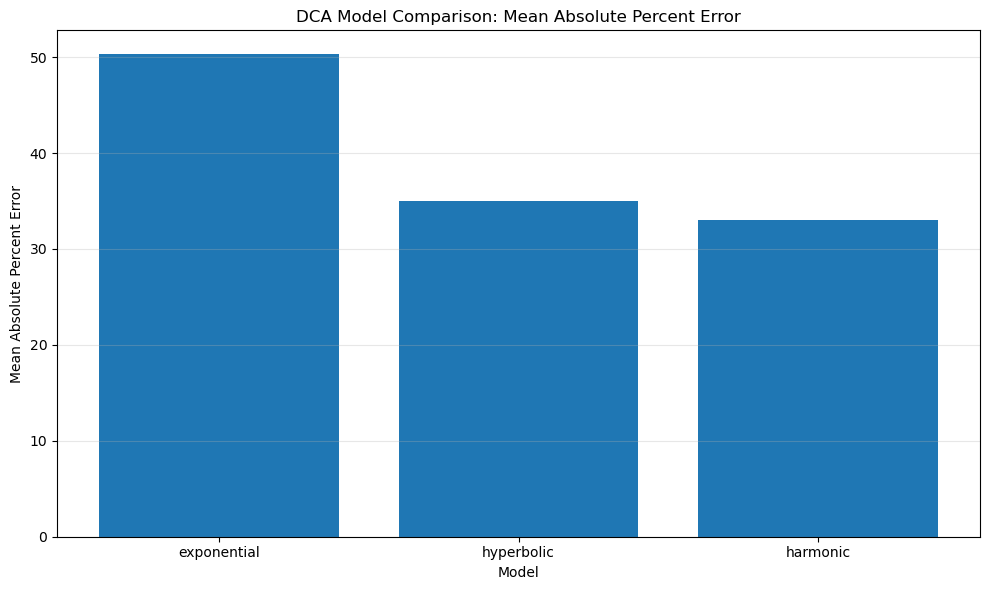

In [31]:
plt.figure(figsize=(10, 6))

plt.bar(
    dca_model_summary["model"],
    dca_model_summary["mean_absolute_percent_error"],
)

plt.title("DCA Model Comparison: Mean Absolute Percent Error")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Percent Error")
plt.grid(axis="y", alpha=0.30)
plt.tight_layout()
plt.show()

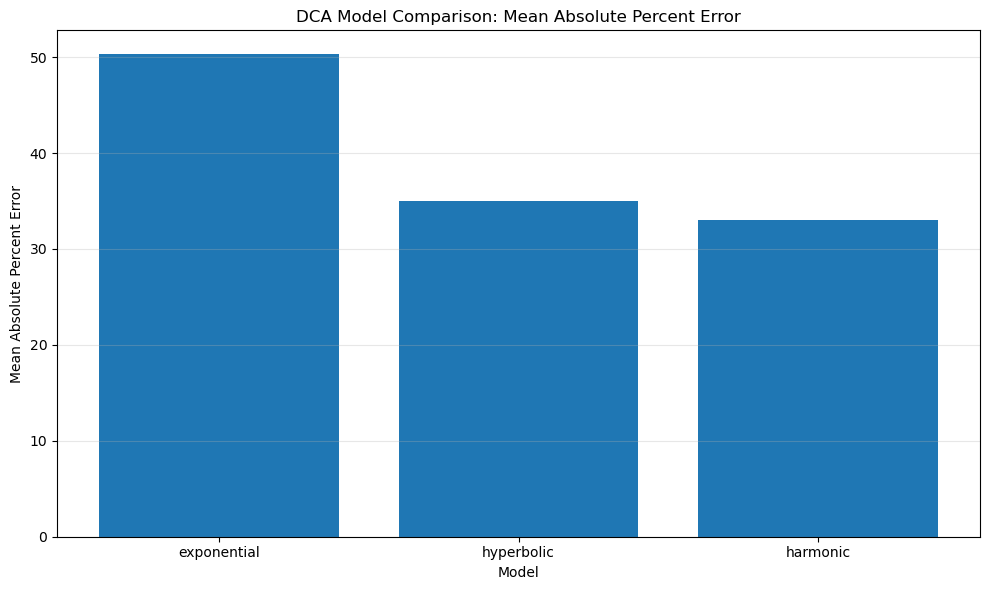

In [33]:
plt.figure(figsize=(10, 6))

plt.bar(
    dca_model_summary["model"],
    dca_model_summary["mean_absolute_percent_error"],
)

plt.title("DCA Model Comparison: Mean Absolute Percent Error")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Percent Error")
plt.grid(axis="y", alpha=0.30)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "dca_all_models_mean_absolute_percent_error.png",
    dpi=150,
)

plt.show()


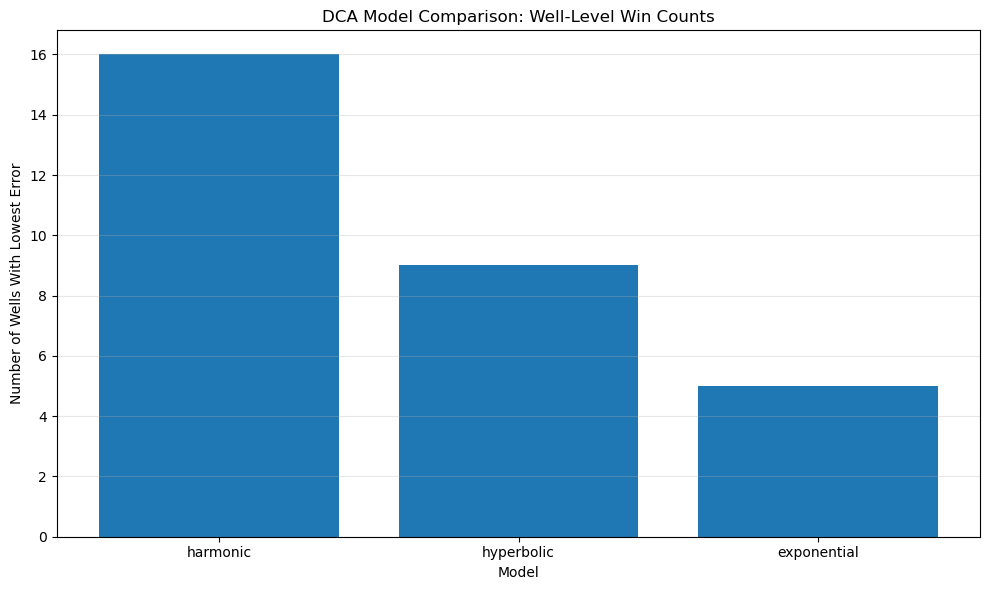

In [35]:
plt.figure(figsize=(10, 6))

plt.bar(
    dca_model_win_counts["model"],
    dca_model_win_counts["well_count"],
)

plt.title("DCA Model Comparison: Well-Level Win Counts")
plt.xlabel("Model")
plt.ylabel("Number of Wells With Lowest Error")
plt.grid(axis="y", alpha=0.30)
plt.tight_layout()
plt.show()

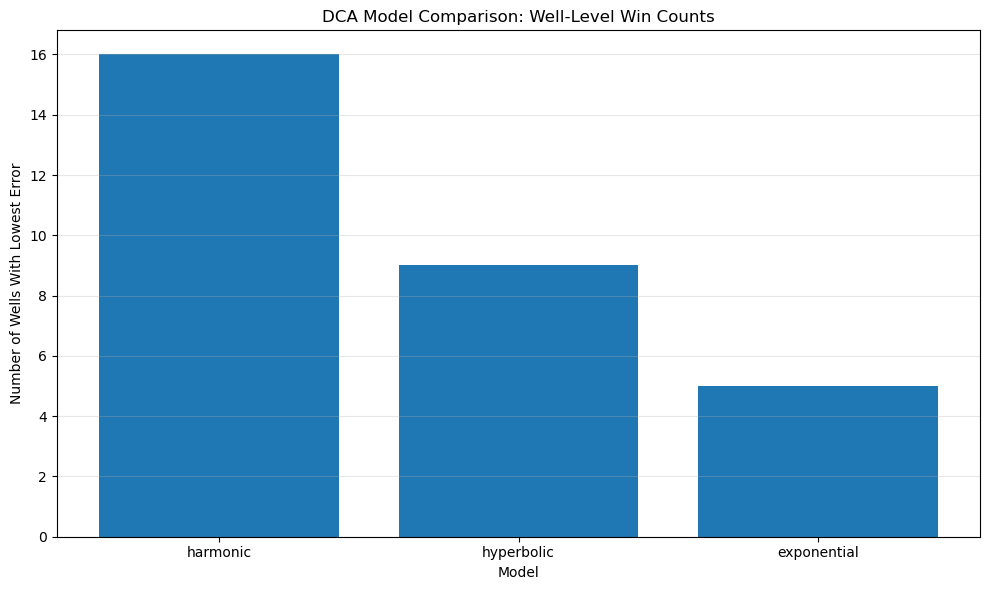

In [37]:
plt.figure(figsize=(10, 6))

plt.bar(
    dca_model_win_counts["model"],
    dca_model_win_counts["well_count"],
)

plt.title("DCA Model Comparison: Well-Level Win Counts")
plt.xlabel("Model")
plt.ylabel("Number of Wells With Lowest Error")
plt.grid(axis="y", alpha=0.30)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "dca_all_models_win_counts.png",
    dpi=150,
)

plt.show()

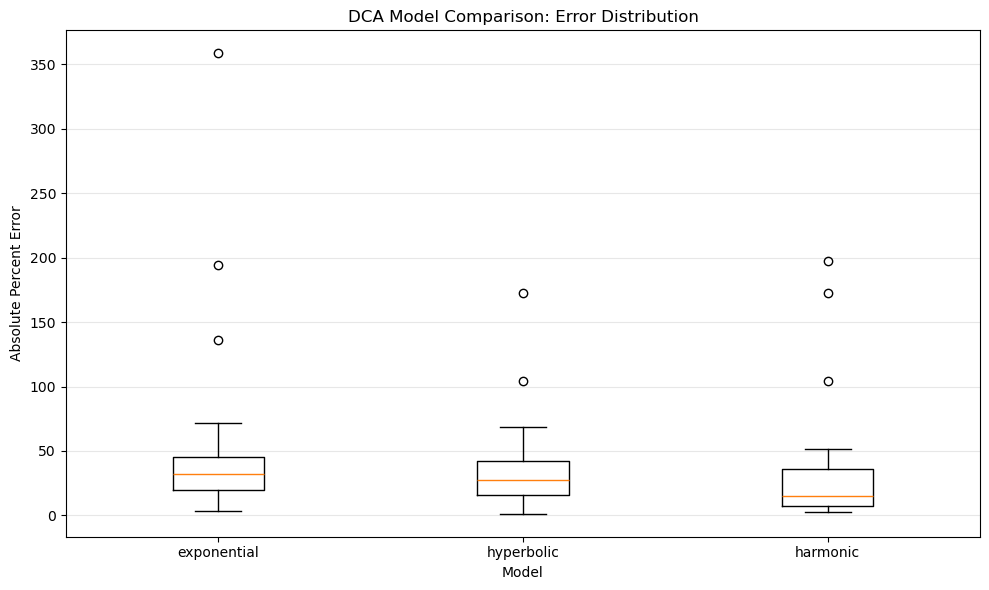

In [39]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        dca_model_comparison["exponential_absolute_percent_error"],
        dca_model_comparison["hyperbolic_absolute_percent_error"],
        dca_model_comparison["harmonic_absolute_percent_error"],
    ],
    labels=[
        "exponential",
        "hyperbolic",
        "harmonic",
    ],
)

plt.title("DCA Model Comparison: Error Distribution")
plt.xlabel("Model")
plt.ylabel("Absolute Percent Error")
plt.grid(axis="y", alpha=0.30)
plt.tight_layout()
plt.show()

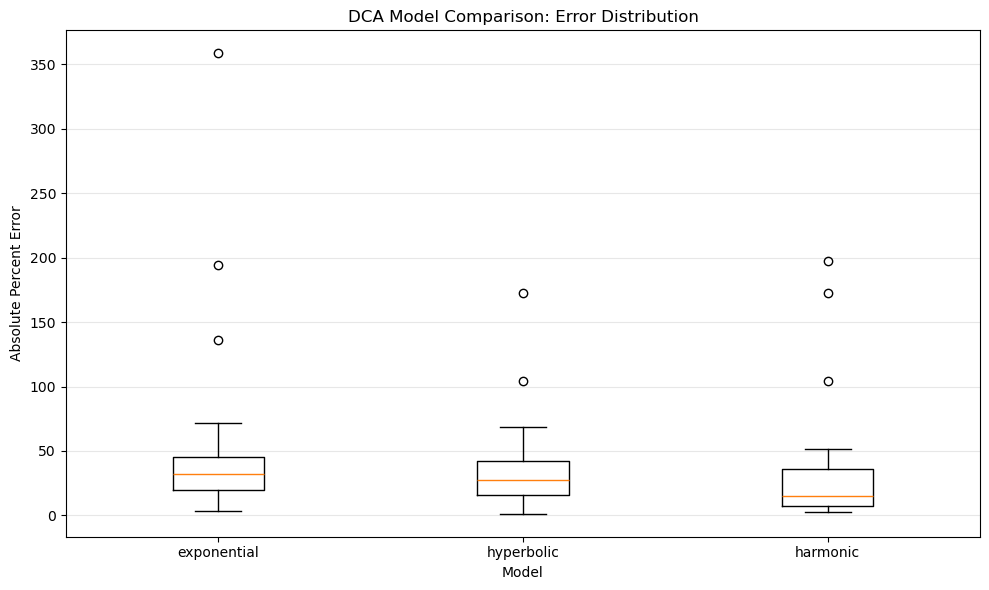

In [41]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        dca_model_comparison["exponential_absolute_percent_error"],
        dca_model_comparison["hyperbolic_absolute_percent_error"],
        dca_model_comparison["harmonic_absolute_percent_error"],
    ],
    labels=[
        "exponential",
        "hyperbolic",
        "harmonic",
    ],
)

plt.title("DCA Model Comparison: Error Distribution")
plt.xlabel("Model")
plt.ylabel("Absolute Percent Error")
plt.grid(axis="y", alpha=0.30)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "dca_all_models_absolute_percent_error_boxplot.png",
    dpi=150,
)

plt.show()

In [43]:
dca_model_comparison["best_absolute_percent_error"] = (
    dca_model_comparison[absolute_error_columns].min(axis=1)
)

hard_dca_wells = (
    dca_model_comparison
    .sort_values("best_absolute_percent_error", ascending=False)
    [
        [
            "api8",
            "lease_name",
            "well_no",
            "best_model",
            "best_absolute_percent_error",
            "exponential_absolute_percent_error",
            "hyperbolic_absolute_percent_error",
            "harmonic_absolute_percent_error",
        ]
    ]
    .head(10)
)

hard_dca_wells


,api8,lease_name,well_no,best_model,best_absolute_percent_error,exponential_absolute_percent_error,hyperbolic_absolute_percent_error,harmonic_absolute_percent_error
28,31744069,DAVIS-LACY 31D,204H,hyperbolic,172.608041,194.085074,172.608041,172.672371
27,31743568,WELCH-COX E39T,320H,harmonic,104.469701,135.787593,104.494243,104.469701
4,31743757,GLYNN-ATCHISON 44M,213H,exponential,45.888341,45.888341,50.028355,49.443855
26,31743549,WELCH-COX E39V,322H,exponential,38.413792,38.413792,42.897469,197.053916
0,31744055,DAVIS-LACY 31K,211H,harmonic,38.272338,71.532978,68.959435,38.272338
5,31744058,DAVIS-LACY 31H,208H,harmonic,29.430236,42.859528,41.562248,29.430236
7,31744057,DAVIS-LACY 31I,209H,harmonic,27.767237,38.360463,32.525936,27.767237
25,31744071,DAVIS-LACY 31B,202H,exponential,27.434165,27.434165,29.239599,42.468516
1,31744070,DAVIS-LACY 31C,203H,harmonic,22.909488,63.314796,61.726277,22.909488
13,31744056,DAVIS-LACY 31J,210H,hyperbolic,22.330681,25.694044,22.330681,51.473118


In [45]:
hard_dca_wells.to_csv(
    OUTPUT_DIR / "dca_hardest_wells_all_models.csv",
    index=False,
)

## DCA Model Comparison Checkpoint

We compared per-well exponential, hyperbolic, and harmonic decline forecasts.

Shared setup:

- Wells: 30
- Fit window: months 12-24
- Forecast-check window: months 25-33
- Target: total oil production over months 25-33

Comparison method:

- Each model was evaluated using absolute percent error by well.
- The model with the lowest absolute percent error was labeled as the best model for that well.
- Model-level summaries were calculated using mean and median absolute percent error, plus signed percent error for bias.
- Hard wells were identified as wells where even the best DCA model still had high absolute percent error.

Outputs created:

- `dca_all_models_per_well_comparison.csv`
- `dca_all_models_summary.csv`
- `dca_all_models_win_counts.csv`
- `dca_all_models_mean_absolute_percent_error.png`
- `dca_all_models_win_counts.png`
- `dca_all_models_absolute_percent_error_boxplot.png`
- `dca_hardest_wells_all_models.csv`

Interpretation questions:

- Which model has the lowest mean absolute percent error?
- Which model has the lowest median absolute percent error?
- Which model wins on the most individual wells?
- Which wells remain difficult for all smooth decline models?
- Does hyperbolic flexibility materially improve performance compared with exponential or harmonic decline?

Project decision:

This comparison creates the classical DCA benchmark set. The next modeling step is to build simple machine learning baselines and compare them against these DCA results.

## DCA Model Comparison Closing Notes

This notebook completed the side-by-side comparison of classical DCA models.

Models compared:

- Exponential decline
- Hyperbolic decline
- Harmonic decline

Completed work:

- Loaded saved per-well DCA outputs from separate notebooks.
- Standardized model-specific columns for comparison.
- Merged all three models into one well-level comparison table.
- Identified the best DCA model for each well.
- Counted model-level wins across wells.
- Summarized average, median, and signed forecast errors.
- Identified wells that remain difficult for all DCA models.
- Saved comparison tables and plots.

Key observations to write after reviewing your tables:

- Which model had the lowest mean absolute percent error?
- Which model had the lowest median absolute percent error?
- Which model won the most wells?
- Whether one model showed stronger overprediction or underprediction bias.
- Which wells were hard for all three DCA models.

Files saved:

- `dca_all_models_per_well_comparison.csv`
- `dca_all_models_summary.csv`
- `dca_all_models_win_counts.csv`
- `dca_hardest_wells_all_models.csv`
- `dca_all_models_mean_absolute_percent_error.png`
- `dca_all_models_win_counts.png`
- `dca_all_models_absolute_percent_error_boxplot.png`

Next project step:

Build simple machine learning forecast baselines using the same train/test split, then compare ML performance against these classical DCA benchmarks.